In [1]:
!pip install Palmto-gen

**Load Data:**  The Palmto_gen package has a sample file of 30k taxi trajectories from the city of Porto included that we can use for demonstration.

In [4]:
!pip install pyarrow
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 599.4 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 1.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 13.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 3.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 17.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 774.6 kB/s eta 0:00:00a 0:00:01


In [5]:
import pandas as pd
from importlib.resources import files

sample_data_path = files('Palmto_gen').joinpath('data/rotas_agrupadas.pkl')

df = pd.read_pickle(sample_data_path)
df.head()

,trip_id,geometry
0,B10098,"[[-43.18776, -22.81521], [-43.18776, -22.81521..."


Next, we convert the trajectories into *'sentences'* using the following steps:
1. **Create Shapely Points:** For each latitude-longitude coordinate pair, create a Shapely Point object.
2. **Overlay a Grid**: Overlay a grid of a specific size over the area covered by the trajectories.
3. Assign Unique IDs to Grid Cells
4. **Merge the shapely points with the cell:** representing each point by the ID of the cell it fall into.

In [8]:
import geopandas as gpd
from Palmto_gen import ConvertToToken
from importlib.resources import files

# Substituindo o pkg_resources pela abordagem moderna
study_area_path = files('Palmto_gen').joinpath('data/Centro.geojson')

# O GeoPandas também consegue ler direto do caminho gerado
study_area = gpd.read_file(study_area_path)

# Executando o resto do seu código normalmente
TokenCreator = ConvertToToken(df, study_area, cell_size=50)
grid, sentence_df = TokenCreator.create_tokens()

# Mostrando os resultados
print(sentence_df.head())

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 54.34it/s]


Number of created cells:  111496
                                                  geometry  \
trip_id                                                      
B10098   [POINT (-43.18776 -22.81521), POINT (-43.18776...   

                                                        ID  
trip_id                                                     
B10098   [(230, 254), (230, 254), (230, 254), (230, 254...  


**Create n-grams:** from the *'sentences'* we formed in the previous step.

In [9]:
from Palmto_gen import NgramGenerator

ngram_model = NgramGenerator(sentence_df)
ngrams, start_end_points = ngram_model.create_ngrams()

100%|██████████| 1/1 [00:00<00:00, 639.96it/s]


Number of Unique Bigrams: 1259 
Number of Unique Trigrams: 1383


**Approach 1: Generating length-constrained trajectories
from a given point**

Start the process by selecting a token from
our bigram corpus and specifying the length (number of points) for
our trajectory and the number of new trajectories we want. The model then proceeds to construct the trajectory by iteratively generating and adding points
until the predetermined length is reached.

In [10]:
from Palmto_gen import TrajGenerator

n = 10000
sentence_length = 30
traj_generator = TrajGenerator(ngrams, start_end_points, n, grid)
new_trajs_app1, new_trajs_app1_gdf = traj_generator.generate_trajs_using_origin(sentence_length, seed=None)
new_trajs_app1.head()

100%|██████████| 10000/10000 [00:00<00:00, 398440.55it/s]


,trip_id,geometry
0,1,"[[-43.18764353233524, -22.81510151729635], [-4..."
1,2,"[[-43.18764353233524, -22.81510151729635], [-4..."
2,3,"[[-43.18764353233524, -22.81510151729635], [-4..."
3,4,"[[-43.18764353233524, -22.81510151729635], [-4..."
4,5,"[[-43.18764353233524, -22.81510151729635], [-4..."


**Approach 2: Generating trajectories between two given
points**

Select one origin and one destination point
from one of our original trajectories and generate trajectories that
connect these two points.

In [ ]:
n = 10000
traj_generator = TrajGenerator(ngrams, start_end_points, n, grid)
new_trajs_app2, new_trajs_app2_gdf = traj_generator.generate_trajs_using_origin_destination()
new_trajs_app2.head()

100%|██████████| 10000/10000 [00:00<00:00, 111615.95it/s]


,trip_id,geometry
0,1,"[[-43.18855709470876, -22.814745795187893], [-..."
1,2,"[[-43.18855709470876, -22.814745795187893], [-..."
2,3,"[[-43.18416521953827, -22.797137430940975], [-..."
3,4,"[[-43.16903764950661, -22.825581711647533], [-..."
4,5,"[[-43.19831681730983, -22.8183577673411], [-43..."


**Save the new dataset.**

In [ ]:
new_trajs_app1.to_pickle('generated_trajs_app1.pkl')
new_trajs_app1.to_csv('generated_trajs_app1.csv')

**Plot**: a sample of 1000 trajectories from the original dataset and the dataset generated using approach 1.

In [11]:
from Palmto_gen import DisplayTrajs

# Calcula o tamanho máximo da amostra
tamanho_amostra_original = min(1000, len(sentence_df))
tamanho_amostra_gerado = min(1000, len(new_trajs_app1_gdf))

original_trajs = sentence_df['geometry'].sample(tamanho_amostra_original).to_list()
generated_trajs = new_trajs_app1_gdf['geometry'].sample(tamanho_amostra_gerado).to_list()

# Inicia o gerador de mapas
display_trajs = DisplayTrajs(original_trajs, generated_trajs)

# PLANO B: Em vez de tentar mostrar no VS Code, criamos os mapas separadamente
mapa_original = display_trajs.plot_map(original_trajs)
mapa_gerado = display_trajs.plot_map(generated_trajs)

# Salvamos como arquivos de site (.html)
mapa_original.save("mapa_original.html")
mapa_gerado.save("mapa_gerado.html")

print("Mapas gerados! Vá na pasta do seu projeto e dê um duplo clique nos arquivos .html")

Mapas gerados! Vá na pasta do seu projeto e dê um duplo clique nos arquivos .html


**Plot**: a sample of 1000 trajectories from the original dataset and the dataset generated using approach 2.


In [ ]:
from Palmto_gen import DisplayTrajs

# 1. Trava de segurança para não pedir mais trajetos do que o banco possui
tamanho_amostra_original = min(1000, len(sentence_df))
tamanho_amostra_gerado = min(1000, len(new_trajs_app2_gdf))

original_trajs = sentence_df['geometry'].sample(tamanho_amostra_original).to_list()
generated_trajs = new_trajs_app2_gdf['geometry'].sample(tamanho_amostra_gerado).to_list()

# 2. Inicia o construtor do mapa
display_trajs = DisplayTrajs(original_trajs, generated_trajs)

# 3. Gerando e salvando os mapas em HTML (Plano B)
mapa_original_app2 = display_trajs.plot_map(original_trajs)
mapa_gerado_app2 = display_trajs.plot_map(generated_trajs)

mapa_original_app2.save("mapa_original_app2.html")
mapa_gerado_app2.save("mapa_gerado_app2.html")

print("Mapas da Abordagem 2 gerados com sucesso! Verifique sua pasta.")

Mapas da Abordagem 2 gerados com sucesso! Verifique sua pasta.


**Heat Map**: comparing the original trajectories with the trajectories generated using approach 1.

100%|██████████| 1/1 [00:00<00:00, 1415.08it/s]

Number of created cells:  460


100%|██████████| 5000/5000 [00:00<00:00, 144667.09it/s]


Number of created cells:  460


100%|██████████| 150000/150000 [00:04<00:00, 32921.45it/s]


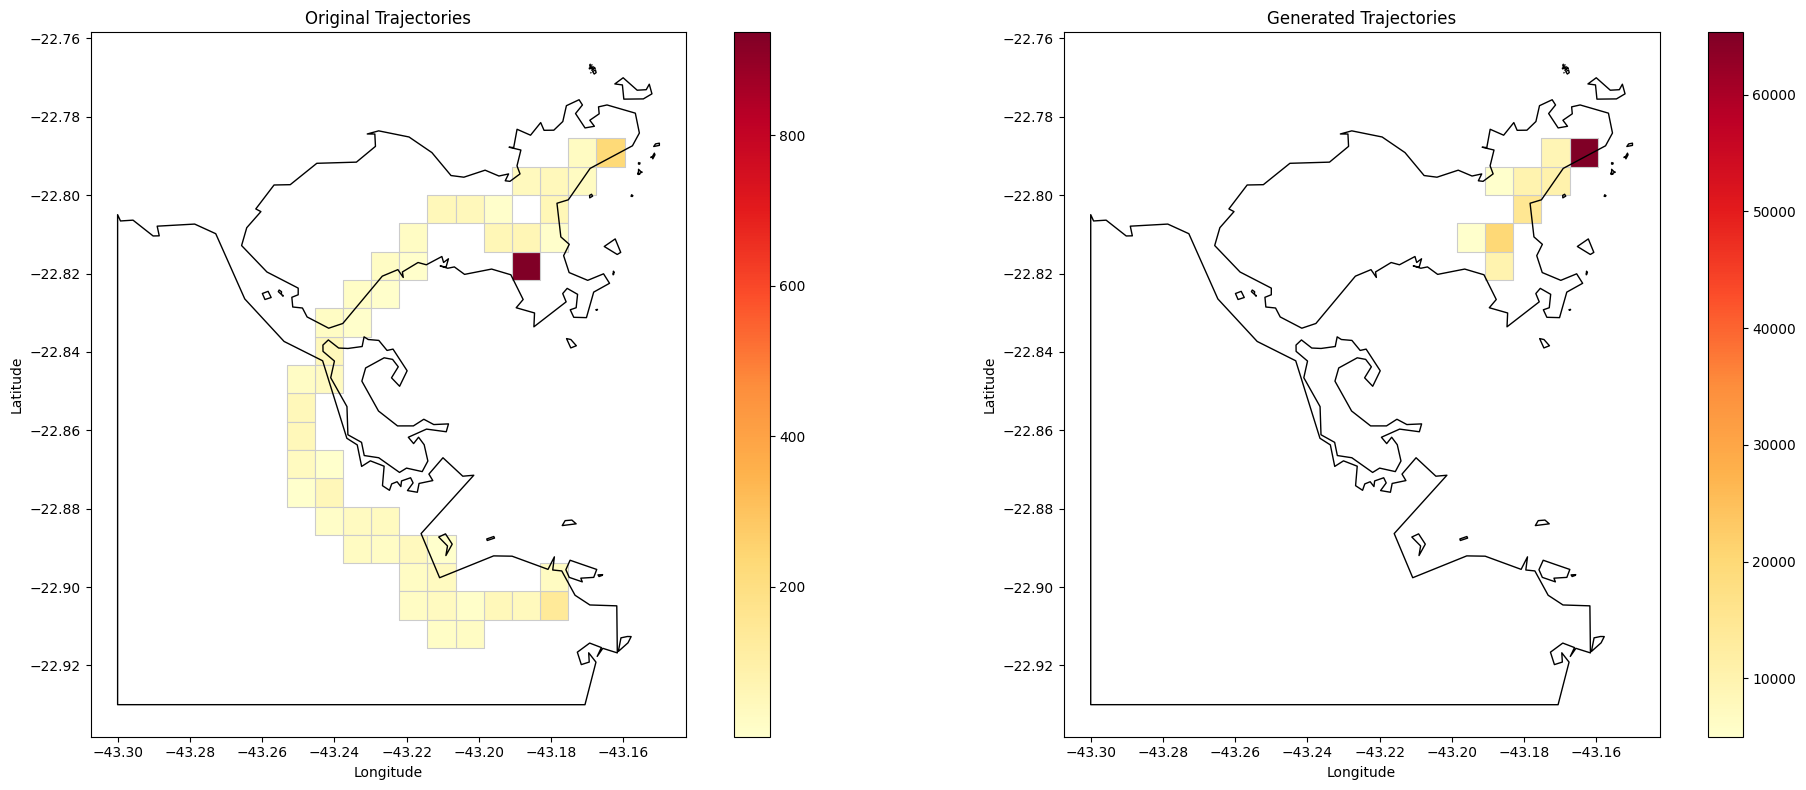

In [12]:
import matplotlib.pyplot as plt

# 1. Trava inteligente para o mapa de calor
tamanho_amostra_original = min(5000, len(sentence_df))
tamanho_amostra_gerado1 = min(5000, len(new_trajs_app1_gdf))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 2. Usa a trava dentro do sample()
display_trajs.plot_heat_map(sentence_df.sample(tamanho_amostra_original), study_area, axes[0], cell_size = 800)
axes[0].set_title('Original Trajectories')

display_trajs.plot_heat_map(new_trajs_app1_gdf.sample(tamanho_amostra_gerado1), study_area, axes[1], cell_size = 800)
axes[1].set_title('Generated Trajectories')

plt.tight_layout()
plt.show()

**Heat Map**: comparing the original trajectories with the trajectories generated using approach 2.

100%|██████████| 61/61 [00:00<00:00, 1005.41it/s]


Number of created cells:  3956


100%|██████████| 5000/5000 [00:00<00:00, 105722.94it/s]


Number of created cells:  3956


100%|██████████| 98076/98076 [00:06<00:00, 15184.51it/s]


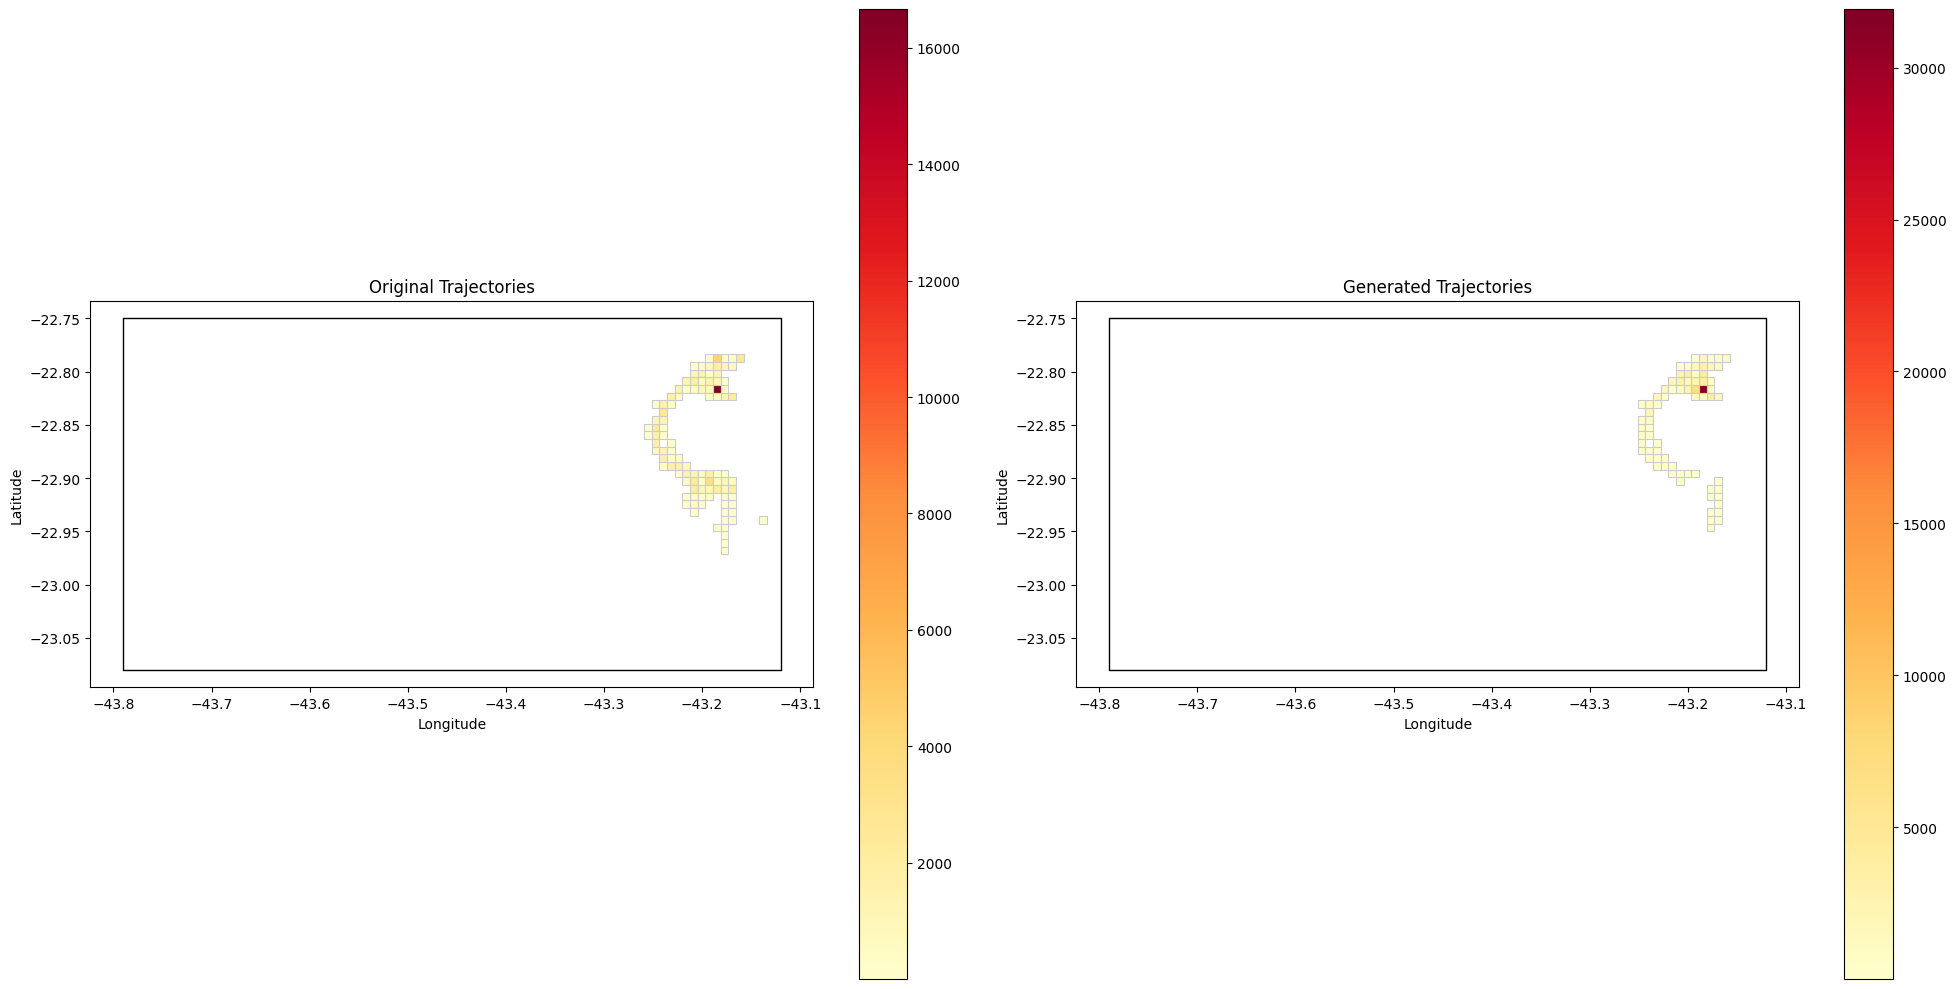

In [ ]:
import matplotlib.pyplot as plt

# 1. Trava inteligente
tamanho_amostra_original = min(5000, len(sentence_df))
tamanho_amostra_gerado2 = min(5000, len(new_trajs_app2_gdf))

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 2. Usa a trava dentro do sample()
display_trajs.plot_heat_map(sentence_df.sample(tamanho_amostra_original), study_area, axes[0], cell_size = 800)
axes[0].set_title('Original Trajectories')

display_trajs.plot_heat_map(new_trajs_app2_gdf.sample(tamanho_amostra_gerado2), study_area, axes[1], cell_size = 800)
axes[1].set_title('Generated Trajectories')

plt.tight_layout()
plt.show()